<a href="https://colab.research.google.com/github/Malicef/Sistemas-Inteligentes-projeto1/blob/main/Regress%C3%A3o_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# buscar conjunto de dados
heart_disease = fetch_ucirepo(id=45)

In [4]:
# dados (como pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

In [5]:
# metadata
print(heart_disease.metadata)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [6]:
# informação de variaveis
print(heart_disease.variables)

        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

**1. No pré-processamento:**

**(a)** Realize o tratamento de valores nulos (verificar especialmente as colunas ca e thal). Caso existam,
escolha o método de imputação através da mediana.

In [7]:
import pandas as pd

Dataframe dos dados do dataset

In [8]:
dados = pd.DataFrame(X, columns=heart_disease.feature_names)
dados['target'] = y
dados.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


A quantidade de amostras do nosso dataset e a quantidade e features

In [9]:
print("O dataset possui: ")
print(f"Quantidade de amostras = {X.shape[0]}")
print(f"Quantidade de features = {X.shape[1]}")

O dataset possui: 
Quantidade de amostras = 303
Quantidade de features = 13


In [10]:
print("Valores nulos por coluna:")
print(dados.isnull().sum())
print(f"\nTotal de valores nulos: {dados.isnull().sum().sum()}")

Valores nulos por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total de valores nulos: 6


A coluna as colunas ca e thal são as unicas afetadas, possuindo valores nulos. A coluna ca possui 4 nulos e a coluna thal possui 2 nulos

Imputação pela mediana.

In [15]:
dados['ca'].fillna(dados['ca'].median(), inplace=True)
dados['thal'].fillna(dados['thal'].median(), inplace=True)

print("Valores nulos por coluna após imputação:")
print(dados.isnull().sum())

Valores nulos por coluna após imputação:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


/tmp/ipykernel_1766/2390056565.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dados['ca'].fillna(dados['ca'].median(), inplace=True)
/tmp/ipykernel_1766/2390056565.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

**(b)** Obtenha a binarização da variável target, transformando os valores originais (0 a 4) em uma variável
binária (0 = sem doença, 1 = com doença).

In [16]:
print("Destribuição da variável target:")
print(dados['target'].value_counts().sort_index())

Destribuição da variável target:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [22]:
dados['target'] = dados['target'].apply(lambda x: 0 if x == 0 else 1)
dados['target'].head(12)

,target
0,0
1,1
2,1
3,0
4,0
5,0
6,1
7,0
8,1
9,1


In [23]:
print("Destribuição da variável target após a binarização:")
print(dados['target'].value_counts().sort_index())

Destribuição da variável target após a binarização:
target
0    164
1    139
Name: count, dtype: int64


**(c)** Realize a divisão treino/teste com proporção de 80/20, usando stratify=y para preservar o balanceamento entre as classes.

In [25]:
from sklearn.model_selection import train_test_split

In [24]:
X = dados.drop('target', axis=1)
y = dados['target']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (303, 13)
Shape de y: (303,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 242 amostras
Teste:  61 amostras


**(d)** Faça o escalonamento das features numéricas contı́nuas (age, trestbps, chol, thalach, oldpeak)
com StandardScaler.

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
colunas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [29]:
scaler = StandardScaler()

X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

X_train_sc[colunas] = scaler.fit_transform(X_train[colunas])
X_test_sc[colunas]  = scaler.transform(X_test[colunas])

**2. Treinar um modelo de LogisticRegression do scikit-learn utilizando os dados de treino, com os
seguintes parâmetros: solver=’liblinear’, random state=42 e max iter=1000. Indique quantas
iterações foram necessárias para a convergência do modelo.**

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
modelo = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

In [32]:
modelo.fit(X_train_sc, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [35]:
print("Numero de iterações necessarias para a convergencia: ", modelo.n_iter_)

Numero de iterações necessarias para a convergencia:  [5]


In [36]:
pred = modelo.predict(X_test_sc)
prob = modelo.predict_proba(X_test_sc)[:,1]

**3. Avaliar o modelo utilizando os dados de teste e calcular as seguintes métricas:**

**(a)** Acurácia
**(b)** Precisção
**(c)** Recall
**(d)** F1-score
**(e)** Curva ROC com valor de AUC.

In [37]:
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score)

In [39]:
print(f"Acurácia: {accuracy_score(y_test, pred):.4f}")
print(f"Precisão: {precision_score(y_test, pred):.4f}")
print(f"Recall: {recall_score(y_test, pred):.4f}")
print(f"F1-Score: {f1_score(y_test, pred):.4f}")

Acurácia: 0.8689
Precisão: 0.8125
Recall: 0.9286
F1-Score: 0.8667


In [41]:
import matplotlib.pyplot as plt

AUC-ROC:  0.9545


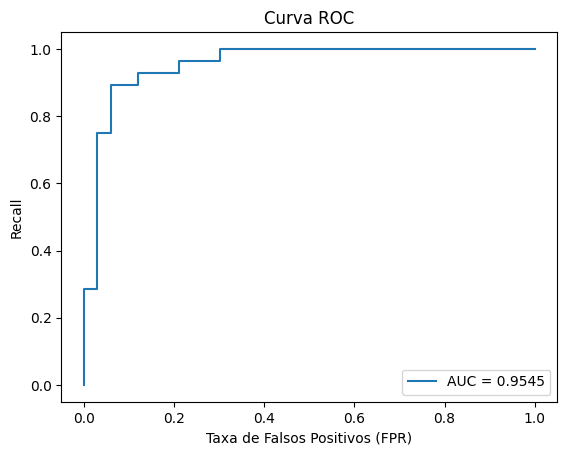

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, prob)
auc = roc_auc_score(y_test, prob)

print(f"AUC-ROC:  {roc_auc_score(y_test, prob):.4f}")

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Recall')
plt.title('Curva ROC')
plt.legend()
plt.show()
